# Projekt Dyplomowy 2026

**Autor:** Paweł Myszka 331720

**Temat:** Wyznaczanie poziomów Fibonacciego pod kątem możliwego zastosowania w modelach klasyfikacyjnych (lasy losowe).

# 1. Wczytanie potrzebnych bibliotek

In [51]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
from scipy.signal import argrelextrema
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from collections import Counter

# 2. Pobranie danych giełodwych i uporządkowanie data frame.

In [110]:
ticker = ("NKE")  # symbol dnaego indeksu, np. "AAPL", "^GSPC", "ETH-USD"
okres  = "5y"       # 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
interwal = "1d"     # 1m, 5m, 15m, 1h, 1d, 1wk, 1mo

df = yf.download(ticker, period=okres, interval=interwal)
df.columns = df.columns.get_level_values(0) 
df = df.reset_index()
df.columns.name = None

print(df.head())

[*********************100%***********************]  1 of 1 completed

        Date       Close        High         Low        Open   Volume
0 2021-03-30  123.240723  123.611519  121.637068  122.684549  6026600
1 2021-03-31  123.185097  124.380882  122.285934  123.370488  6878900
2 2021-04-01  122.851410  124.853670  122.554787  124.853670  5720600
3 2021-04-05  125.252235  125.771337  123.379765  123.379765  5508900
4 2021-04-06  127.143288  127.653124  125.076133  125.548897  4670100


**Przetwarzanie data frame:**

1 Usunięcie podowojnych nagłówków (yfinance zwraca wielopoziomowe kolumny, gydbyśmy chcieli pobrać więcej niż jeden indeks).

2 Ustawienie date jako kolumny a nie jako indeks

3 Price ustawia się jako id- usuwamy to aby tabela wyglądała czysto

**Opis pobranych danych:**

Open- cena otwarcia świecy

High — najwyższa cena w ciągu dnia

Low — najniższa cena w ciągu dnia

Close — cena zamknięcia świecy (na końcu dnia)

Volume — wolumen, czyli ile BTC zostało sprzedane w ciągu dnia

**Wstępne wiadomości o pobranych danych**

In [111]:
print(f"Liczba rekordów: {len(df)}")
print(f"Zakres dat: {df['Date'].min()} — {df['Date'].max()}")
print(f"\nBrakujące wartości:")
print(df.isnull().sum())
print(f"\nTypy danych:")
print(df.dtypes)

Liczba rekordów: 1256
Zakres dat: 2021-03-30 00:00:00 — 2026-03-30 00:00:00

Brakujące wartości:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Typy danych:
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object


# Wizualizacja wykresu

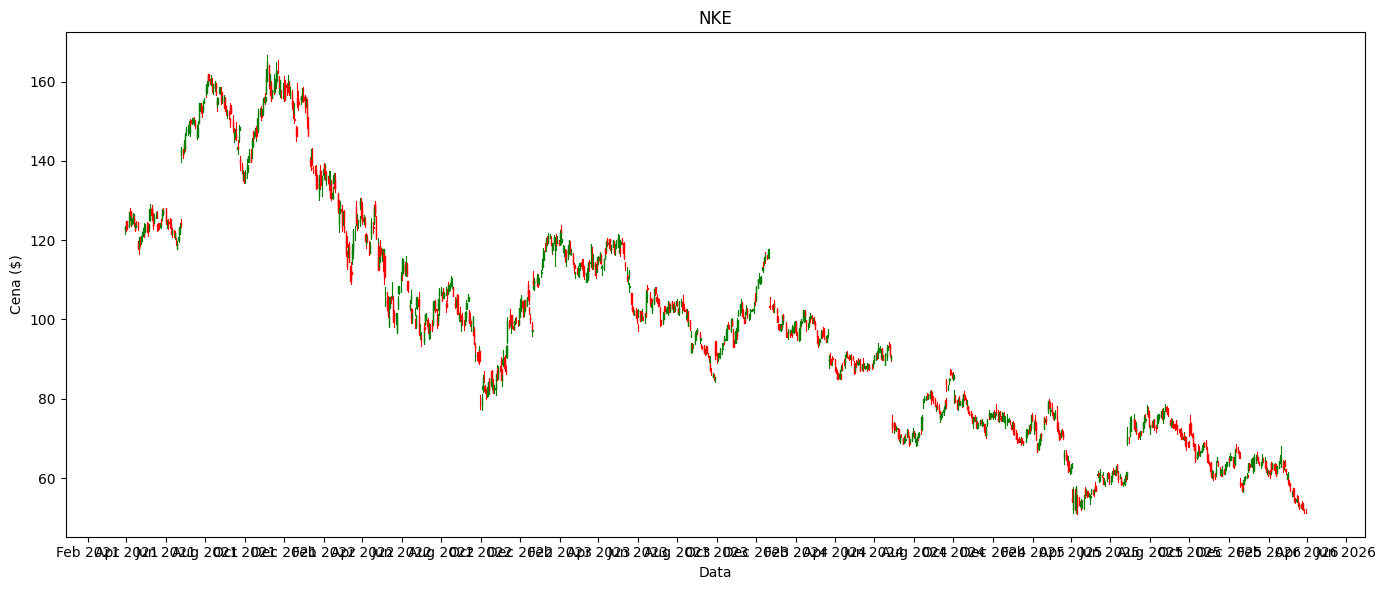

In [112]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Sprawdzenie lokalnych punktów min/max

In [113]:
n = 5 #ile swiec sprawdzamy z kazdej strony
df["swing_high"] = np.nan
df["swing_low"] = np.nan

df.loc[argrelextrema(df["High"].values, np.greater_equal, order=n)[0], "swing_high"] = df["High"] # znajdowanie numery wieszy lokalnyh maks
df.loc[argrelextrema(df["Low"].values, np.less_equal, order=n)[0], "swing_low"] = df["Low"] # znajdowanie numery wieszy lokalnyh min

print(f"Swing high: {df['swing_high'].notna().sum()}")
print(f"Swing low:  {df['swing_low'].notna().sum()}")

Swing high: 71
Swing low:  78


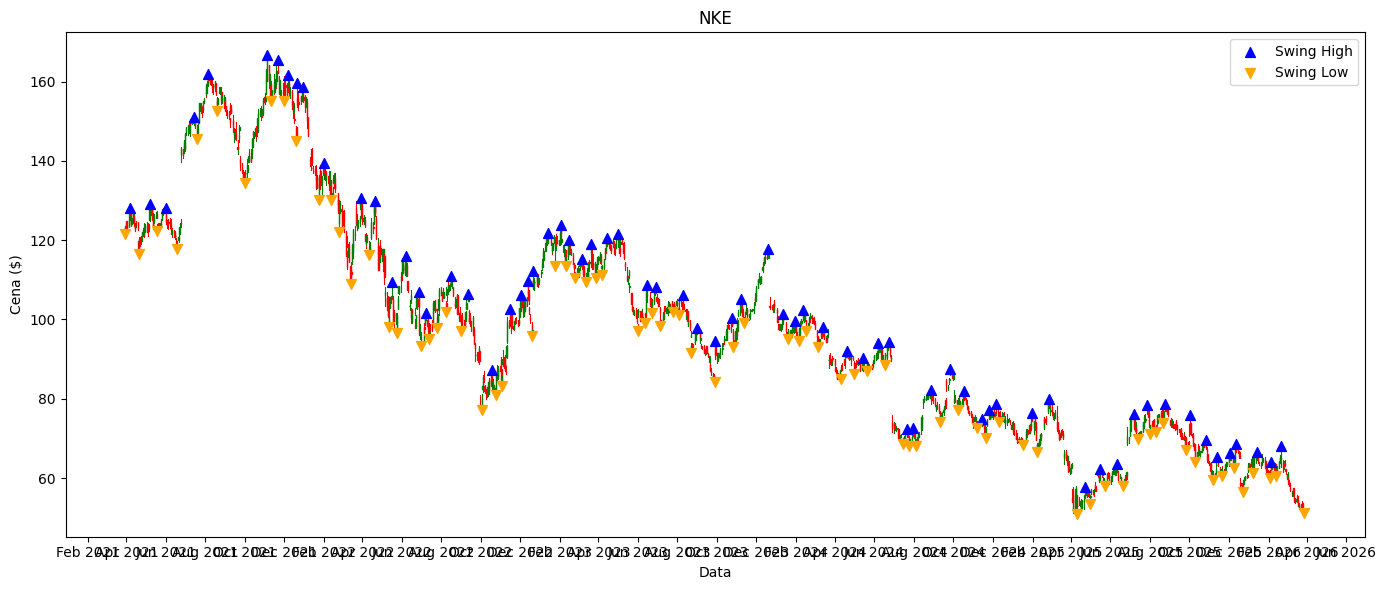

In [114]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Wyznaczenie lini trendów

In [115]:
swing_points = []

for i, row in df.iterrows():
    if not np.isnan(row["swing_high"]):
        swing_points.append((row["Date"], row["swing_high"], "high"))
    if not np.isnan(row["swing_low"]):
        swing_points.append((row["Date"], row["swing_low"], "low"))

swing_points.sort(key=lambda x: x[0])

trends = []
for i in range(len(swing_points) - 1):
    a, b = swing_points[i], swing_points[i + 1]
    if a[2] == "low" and b[2] == "high":
        trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "wzrost"})
    elif a[2] == "high" and b[2] == "low":
        trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "spadek"})

print(f"Liczba trendów: {len(trends)}")

Liczba trendów: 124


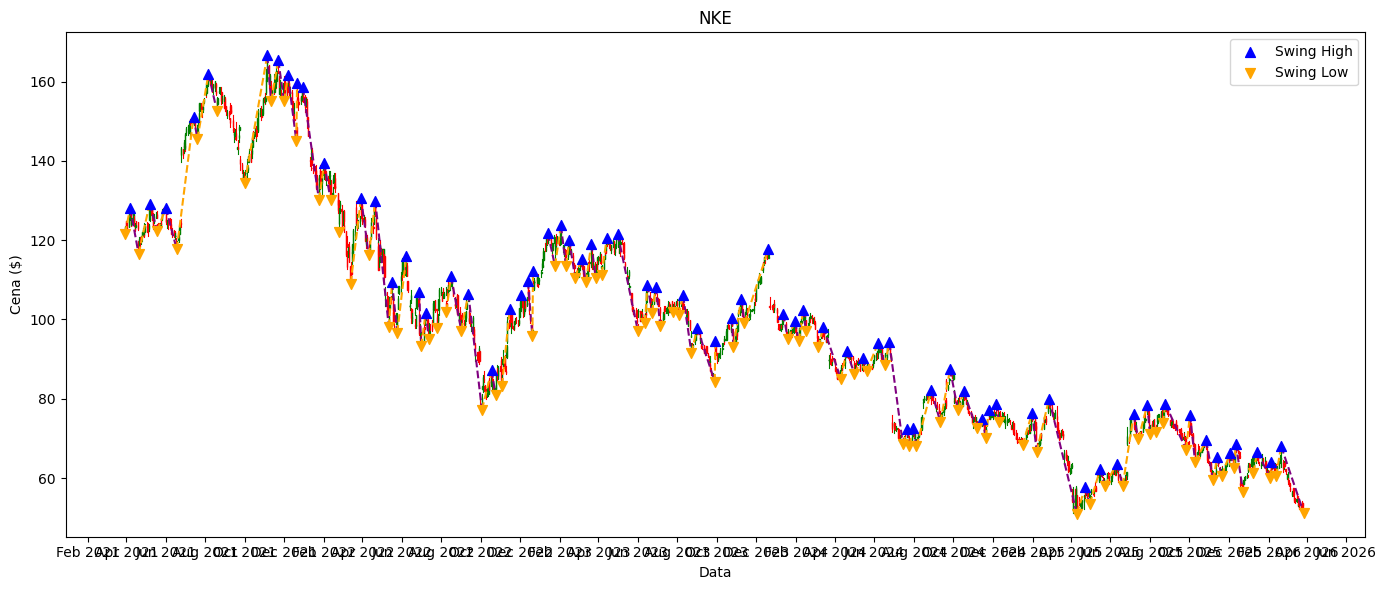

In [116]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()
for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Wyznaczanie poziomów fibonnaciego

In [117]:
LEVELS = [0, 0.38, 0.5, 0.61, 0.707, 0.878, 1, 1.272, 1.618, 2.058, 2.618, 0.8, 0.236, 0.44, 0.577, 0.667, 0.786, 0.941, 1.13, 1.414, 1.732, 2.236, 0.278, 0.77]
#LEVELS = [0.236, 0.382, 0.5, 0.618, 0.786]
fib_zones = []

for t in trends:
    high = t["end_price"] if t["typ"] == "wzrost" else t["start_price"]
    low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]
    
    for level in LEVELS:
        price = high - (high - low) * level
        fib_zones.append({
            "start_date": t["start_date"],
            "end_date":   t["end_date"],
            "level":      level,
            "price":      price,
            "typ":        t["typ"]
        })

print(f"Liczba stref: {len(fib_zones)}")
print(fib_zones[:3])

Liczba stref: 2976
[{'start_date': Timestamp('2021-03-30 00:00:00'), 'end_date': Timestamp('2021-04-07 00:00:00'), 'level': 0, 'price': 128.14440360411803, 'typ': 'wzrost'}, {'start_date': Timestamp('2021-03-30 00:00:00'), 'end_date': Timestamp('2021-04-07 00:00:00'), 'level': 0.38, 'price': 125.671615954509, 'typ': 'wzrost'}, {'start_date': Timestamp('2021-03-30 00:00:00'), 'end_date': Timestamp('2021-04-07 00:00:00'), 'level': 0.5, 'price': 124.89073564410614, 'typ': 'wzrost'}]


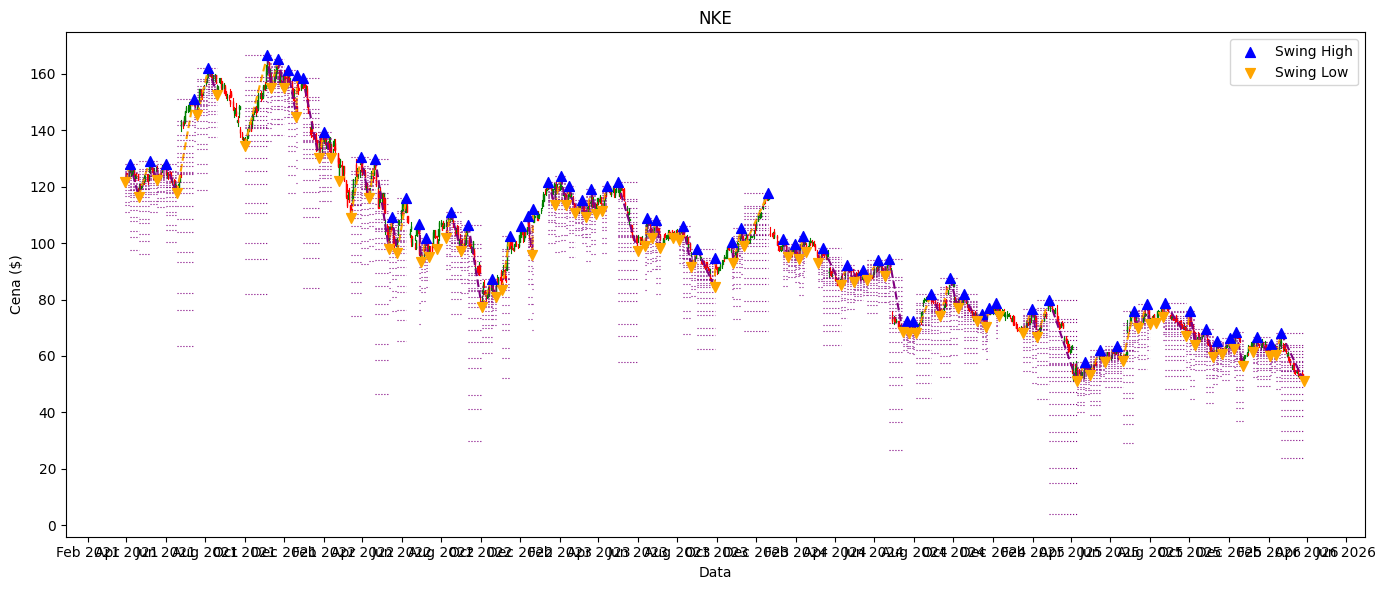

In [118]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones:
    ax.hlines(z["price"], z["start_date"], z["end_date"], 
              colors="purple", linewidth=0.8, linestyle=":")
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Agregacja stref

In [119]:
N_TRENDOW = 3
N_SWIEC   = 20
tolerance = 0.02

def agreguj_strefy(poziomy_z_levelami, tolerance):
    """
    poziomy_z_levelami: lista krotek (cena, level)
    Zwraca: lista krotek (srednia_cena, dominujacy_level)
    """
    poziomy_z_levelami = sorted(poziomy_z_levelami, key=lambda x: x[0])
    grupy  = []
    grupa  = [poziomy_z_levelami[0]]

    for p in poziomy_z_levelami[1:]:
        if (p[0] - grupa[-1][0]) / grupa[-1][0] < tolerance:
            grupa.append(p)
        else:
            dom_level = Counter([x[1] for x in grupa]).most_common(1)[0][0]
            grupy.append((np.mean([x[0] for x in grupa]), dom_level))
            grupa = [p]

    dom_level = Counter([x[1] for x in grupa]).most_common(1)[0][0]
    grupy.append((np.mean([x[0] for x in grupa]), dom_level))
    return grupy


fib_zones_new = []

for i in range(N_TRENDOW, len(trends)):
    ostatnie_trendy = trends[i - N_TRENDOW:i]

    poziomy = []  # lista krotek (cena, level)
    for t in ostatnie_trendy:
        high = t["end_price"]   if t["typ"] == "wzrost" else t["start_price"]
        low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]
        for level in LEVELS:
            poziomy.append((high - (high - low) * level, level))

    grupy = agreguj_strefy(poziomy, tolerance)

    end_date = trends[i]["end_date"]
    future   = df[df["Date"] > end_date]["Date"]
    line_end = future.iloc[N_SWIEC - 1] if len(future) >= N_SWIEC else df["Date"].iloc[-1]

    for cena, level in grupy:
        fib_zones_new.append({
            "price":       cena,
            "level":       level,   # <── teraz jest!
            "start":       end_date,
            "end":         line_end,
            "typ":         trends[i]["typ"],
            "trend_idx":   i,
            "trend_start": trends[i]["start_date"],
            "trend_end":   trends[i]["end_date"],
        })

print(f"Liczba stref: {len(fib_zones_new)}")

Liczba stref: 749


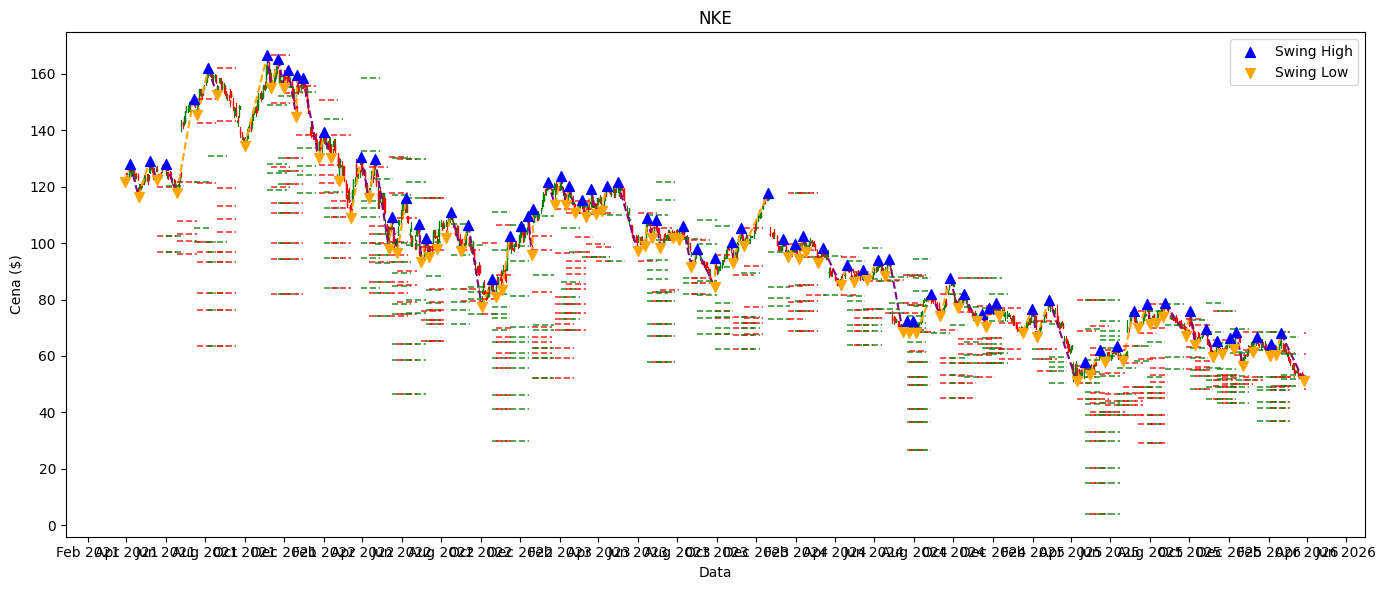

In [120]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones_new:
    kolor = "green" if z["typ"] == "wzrost" else "red"
    ax.hlines(z["price"], z["start"], z["end"],
              colors=kolor, linewidth=1.2, linestyle="--", alpha=0.8)
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Etykietowanie stref

In [121]:
TOLERANCJA_ODBICIA = 0.02

def etykietuj_strefy(fib_zones_new, df):
    for z in fib_zones_new:
        swiece = df[(df["Date"] > z["start"]) & (df["Date"] <= z["end"])].copy()
        
        trafiona = False
        data_odbicia = None
        
        for _, s in swiece.iterrows():
            if z["typ"] == "spadek":
                if abs(s["Low"] - z["price"]) / z["price"] < TOLERANCJA_ODBICIA:
                    trafiona = True
                    data_odbicia = s["Date"]
                    break
            else:
                if abs(s["High"] - z["price"]) / z["price"] < TOLERANCJA_ODBICIA:
                    trafiona = True
                    data_odbicia = s["Date"]
                    break
        
        z["etykieta"] = "trafiona" if trafiona else "nietrafiona"
        z["data_odbicia"] = data_odbicia
    
    return fib_zones_new

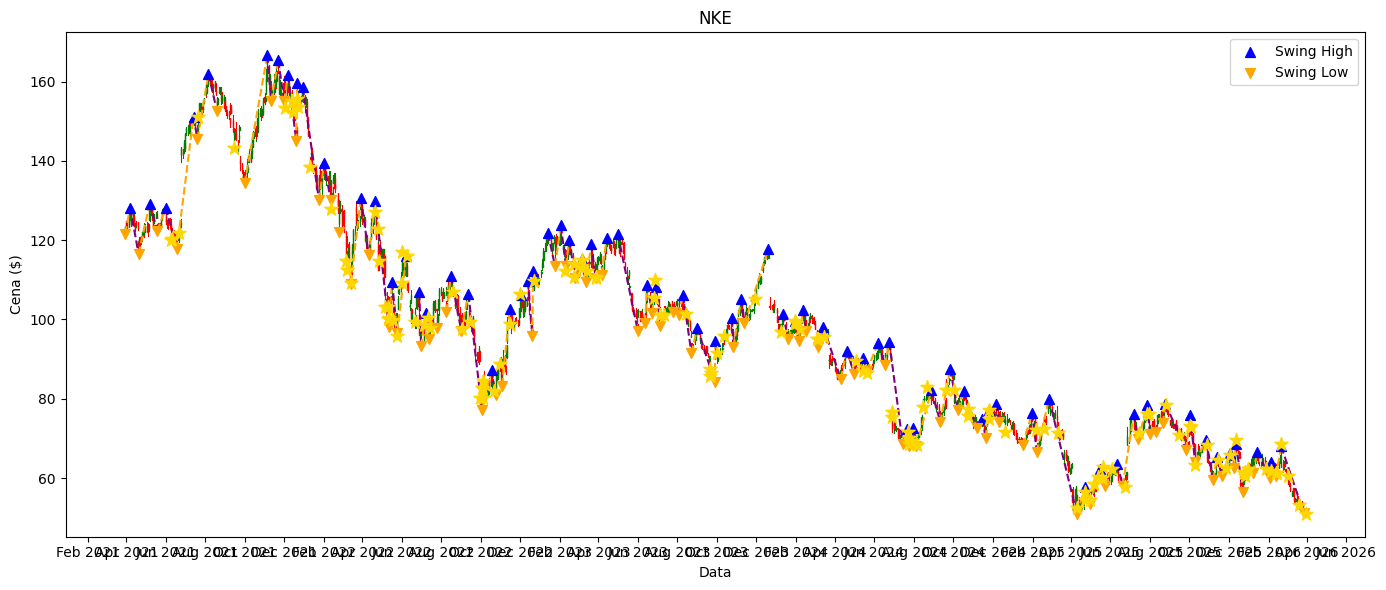

In [122]:
fib_zones_new = etykietuj_strefy(fib_zones_new, df)

fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones_new:
    if z["etykieta"] == "trafiona" and z["data_odbicia"] is not None:
        ax.scatter(z["data_odbicia"], z["price"], 
                   color="gold", marker="*", s=100, zorder=6)
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Generowanie cech dla modelu 

In [123]:
def generuj_cechy(fib_zones_new, df, trends):
    dane = []

    # Prekalkulacja RSI i ATR dla całego df (żeby nie liczyć w pętli)
    def oblicz_rsi(series, okres=14):
        delta = series.diff()
        gain = delta.clip(lower=0).rolling(okres).mean()
        loss = (-delta.clip(upper=0)).rolling(okres).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def oblicz_atr(df, okres=14):
        hl = df["High"] - df["Low"]
        hc = (df["High"] - df["Close"].shift()).abs()
        lc = (df["Low"]  - df["Close"].shift()).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        return tr.rolling(okres).mean()

    df = df.copy()
    df["RSI"]  = oblicz_rsi(df["Close"])
    df["ATR"]  = oblicz_atr(df)
    df["SMA20"] = df["Close"].rolling(20).mean()
    df["SMA50"] = df["Close"].rolling(50).mean()

    for z in fib_zones_new:
        swiece = df[(df["Date"] > z["start"]) & (df["Date"] <= z["end"])]
        if len(swiece) == 0:
            continue

        # Świeca tuż przed strefą (moment "wejścia")
        df_przed = df[df["Date"] <= z["start"]]
        if len(df_przed) < 2:
            continue
        close_start = df_przed["Close"].iloc[-1]

        # Trend dla tej strefy
        trend = next((t for t in trends if t["end_date"] == z["start"]), None)
        if trend is None:
            continue

        df_trend = df[(df["Date"] >= trend["start_date"]) & (df["Date"] <= trend["end_date"])]
        dlugosc_trendu = len(df_trend)
        zmiana_trendu  = (trend["end_price"] - trend["start_price"]) / trend["start_price"]

        # --- Cechy kontekstu rynkowego w momencie wejścia w strefę ---
        rsi_wejscie  = df_przed["RSI"].iloc[-1]
        atr_wejscie  = df_przed["ATR"].iloc[-1]
        sma20        = df_przed["SMA20"].iloc[-1]
        sma50        = df_przed["SMA50"].iloc[-1]
        trend_sma    = 1 if sma20 > sma50 else 0   # 1 = krótkoterm. trend wzrostowy

        # --- Który poziom Fibonacciego ---
        poziom_fib = z["level"]

        # --- Siła strefy: ile poziomów zlało się w jeden klaster ---
        # (fib_zones_new zawiera już zagregowane ceny, więc liczymy ile oryginalnych
        #  poziomów jest "blisko" tej ceny w tym samym oknie trendu)
        ilosc_w_klastrze = sum(
            1 for other in fib_zones_new
            if other["trend_idx"] == z["trend_idx"]
            and abs(other["price"] - z["price"]) / z["price"] < 0.02
        )

        # --- Wolumen relatywny (vs średnia ostatnich 20 świec przed strefą) ---
        vol_srednia_hist = df_przed["Volume"].iloc[-20:].mean()
        vol_strefa = swiece["Volume"].iloc[0]
        vol_relatywny    = vol_strefa / vol_srednia_hist if vol_srednia_hist > 0 else 1.0

        # --- Odległość ceny strefy od SMA20 (czy strefa leży przy MA?) ---
        odleglosc_od_sma20 = (z["price"] - sma20) / sma20 if sma20 > 0 else 0

        # --- Zmienność w trendzie (ATR / cena) ---
        atr_sredni_trend   = df_trend["ATR"].mean()
        zmiennosc_trendu   = atr_sredni_trend / trend["end_price"] if trend["end_price"] > 0 else 0

        dane.append({
            # --- oryginalne cechy ---
            "odleglosc_od_strefy":  (close_start - z["price"]) / z["price"],
            "wolumen_sredni":        vol_strefa,
            "wolumen_w_trendzie":    df_trend["Volume"].mean(),
            "dlugosc_trendu":        dlugosc_trendu,
            "zmiana_trendu":         zmiana_trendu,
            "typ_trendu":            1 if z["typ"] == "wzrost" else 0,
            # --- nowe cechy ---
            "poziom_fib":            poziom_fib,           # 0.236 / 0.382 / 0.5 / 0.618 / 0.786
            "ilosc_w_klastrze":      ilosc_w_klastrze,     # siła strefy (zbieżność poziomów)
            "vol_relatywny":         vol_relatywny,         # wolumen strefy vs historyczny
            "rsi_wejscie":           rsi_wejscie,           # RSI w momencie wejścia w strefę
            "atr_wejscie":           atr_wejscie,           # ATR = bieżąca zmienność rynku
            "trend_sma":             trend_sma,             # 1 jeśli SMA20 > SMA50
            "odleglosc_od_sma20":    odleglosc_od_sma20,   # czy strefa leży blisko MA
            "zmiennosc_trendu":      zmiennosc_trendu,      # ATR/cena w trendzie
            # --- target ---
            "etykieta":              1 if z["etykieta"] == "trafiona" else 0
        })

    return pd.DataFrame(dane)


df_model = generuj_cechy(fib_zones_new, df, trends)
print(df_model.head())
print(f"\nRozkład etykiet:\n{df_model['etykieta'].value_counts()}")
print(f"\nLiczba cech: {df_model.shape[1] - 1}")  # -1 za etykietę
print(f"\nBrakujące wartości:\n{df_model.isnull().sum()}")

   odleglosc_od_strefy  wolumen_sredni  wolumen_w_trendzie  dlugosc_trendu  \
0             0.272294         4934800        6.219989e+06               9   
1             0.201363         4934800        6.219989e+06               9   
2             0.027215         4934800        6.219989e+06               9   
3             0.289723         5226100        6.049000e+06               9   
4             0.217821         5226100        6.049000e+06               9   

   zmiana_trendu  typ_trendu  poziom_fib  ilosc_w_klastrze  vol_relatywny  \
0      -0.053100           0       2.618                 1       0.776939   
1      -0.053100           0       2.236                 1       0.776939   
2      -0.053100           0       1.732                 1       0.776939   
3       0.048261           1       2.618                 1       0.853915   
4       0.048261           1       2.236                 1       0.853915   

   rsi_wejscie  atr_wejscie  trend_sma  odleglosc_od_sma20  zmiennos

# Podział cech

In [124]:
X = df_model.drop(columns=["etykieta"])
y = df_model["etykieta"]

# chronologiczny podział 80/20
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Treningowy: {len(X_train)} próbek")
print(f"Testowy:    {len(X_test)} próbek")

Treningowy: 599 próbek
Testowy:    150 próbek


# Trening i ocena modelu

In [125]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modele = {
    "Random Forest":        (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test),
    "Drzewo decyzyjne":     (DecisionTreeClassifier(random_state=42), X_train, X_test),
    "SVM":                  (SVC(random_state=42), X_train_scaled, X_test_scaled),
    "Regresja logistyczna": (LogisticRegression(random_state=42), X_train_scaled, X_test_scaled),
}

for nazwa, (model, X_tr, X_te) in modele.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    print(f"{nazwa}:")
    print(f"  Dokładność: {accuracy_score(y_test, y_pred):.2f}")
    print(f"  F1-score:   {f1_score(y_test, y_pred):.2f}")
    print()

Random Forest:
  Dokładność: 0.90
  F1-score:   0.68

Drzewo decyzyjne:
  Dokładność: 0.86
  F1-score:   0.62

SVM:
  Dokładność: 0.82
  F1-score:   0.00

Regresja logistyczna:
  Dokładność: 0.82
  F1-score:   0.00



### TO DO

sprawdzanie tylko pierwszego zamknięcia powyżej/poniżej strefy, bez patrzenia "w przód"

PODODAWANIE WIEKSZEJ ILOSCI wolumenow ZEBY MIEC WIECJE INFO DO MODELU

POSPRAWDZANIE ETYKIET- KTORE NAJBARDZIE JA KTORE NAJMNIEJ PRZYDATNE\

DOROBIC WROZENIE Z FUSOW JEZELI BEDZIE GIT- przewidywanie przyslzosci jezlei dobrze wytrenujemy model